In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
from sklearn.metrics import(mean_absolute_error, mean_squared_error, r2_score)

In [4]:
df= pd.read_csv("/content/ev_car_India_dataset.csv")

In [5]:
df.head()

,Brand,Model,Price,Range,Power,Battery
0,Maruti,SuzukieVitara,15.99,440.0,142.0,49.0
1,Tata,PunchEV,9.69,275.0,87.0,30.0
2,Mahindra,XEV9e,21.90,542.0,228.0,59.0
3,Mahindra,BE6,18.90,557.0,228.0,59.0
4,MG,WindsorEV,14.00,332.0,134.0,38.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Brand    26 non-null     object 
 1   Model    26 non-null     object 
 2   Price    26 non-null     float64
 3   Range    26 non-null     float64
 4   Power    26 non-null     float64
 5   Battery  26 non-null     float64
dtypes: float64(4), object(2)
memory usage: 1.3+ KB


In [10]:
df.shape

(26, 6)

In [11]:
df= df.dropna(subset=["Range","Price"])

In [12]:
df[["Range","Price"]].isnull().sum()

,0
Range,0
Price,0


In [13]:
X=df[["Range"]]
y=df["Price"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [17]:
print("Slope",model.coef_[0])
print("Intercept", model.intercept_)

Slope 0.14140952743197052
Intercept -34.39612070941648


In [18]:
y_pred = model.predict(X_test)

In [19]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

In [20]:
print("\nActual vs Predicted:")
print(comparison.head(10))


Actual vs Predicted:
   Actual Price  Predicted Price
0         21.49        41.682205
1         17.29        31.783538
2         15.99        27.824071
3         72.50        33.904681
4          3.25        -9.649453
5          7.99         0.956261


Text(0.5, 1.0, 'Actual vs Predicted EV Prices')

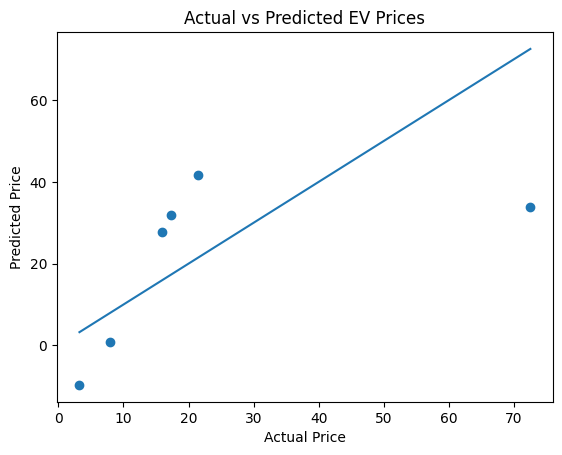

In [21]:
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted EV Prices")

In [24]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("-----------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 :", r2)


Model Evaluation
-----------------
MAE : 17.50805429306669
MSE : 410.5501772136186
RMSE : 20.262037834670494
R2 : 0.21789874655994523
